<a href="https://colab.research.google.com/github/oluaptom-dev/DBN/blob/main/DNB_modulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Differential Binary Noise Modulation

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats, special
from scipy.special import erfc

In [99]:


# função base do DBN

def simulate_dbn(N, snr_db, n_bits, L=100):
  #numero de frame será fixo L= 100 (ou seja a cada 100 simbolos muda vetor u)
  #cada simbolo tem uma repetição do sinal de N - ganho
  # E_u​=  ∥u∥^2  ∼  Gamma  --> está no artigo!

    # --- SNR linear ---
    gamma = 10**(snr_db / 10)

    # --- variâncias ---
    sigma_u = 1.0
    sigma_w = sigma_u / np.sqrt(gamma)

    # ==========================
    # Ajuste: múltiplo de L
    # ==========================
    n_bits = (n_bits // L) * L  # garante blocos completos

    errors = 0
    total_bits = 0

    # ==========================
    # Loop por frames
    # ==========================
    for i in range(0, n_bits, L):

        # ==========================
        # 1. Bits do frame
        # ==========================
        bits = np.random.randint(0, 2, L)

        # ==========================
        # 2. Codificação diferencial
        # ==========================
        s = np.ones(L + 1)
        s[1:] = np.cumprod(1 - 2 * bits)

        # ==========================
        # 3. NOVO u por frame (ESSENCIAL)
        # ==========================
        u = (np.random.normal(0, sigma_u/np.sqrt(2), N) +
             1j * np.random.normal(0, sigma_u/np.sqrt(2), N))

        # ==========================
        # 4. Transmissão
        # ==========================
        X = np.outer(s, u)

        # ==========================
        # 5. Canal AWGN
        # ==========================
        W = (np.random.normal(0, sigma_w/np.sqrt(2), (L + 1, N)) +
             1j * np.random.normal(0, sigma_w/np.sqrt(2), (L + 1, N)))

        Y = X + W

        # ==========================
        # 6. Detector diferencial
        # ==========================
        Z = np.sum(Y[1:] * np.conj(Y[:-1]), axis=1)

        bits_hat = (np.real(Z) < 0).astype(int)

        # ==========================
        # 7. Contagem de erros
        # ==========================
        errors += np.sum(bits != bits_hat)
        total_bits += L

    # ==========================
    # BER final
    # ==========================
    ber = errors / total_bits

    return ber

# ==============================
# 3. Função Q (estável numericamente)
# ==============================
def Q(x):
    # Implementação da função Q usando a função de erro complementar
    return 0.5 * erfc(x / np.sqrt(2))

# ==============================
# 4. BER teórica (aproximação CLT)
# ==============================
def simpl_gauss_approx(N, snr_db):  # Eq 14 do artigo "Differential Binary Noise Modulation"

    gamma = 10**(snr_db / 10)

    num = np.sqrt(N) * gamma
    den = np.sqrt(gamma**2 + gamma + 0.5)

    return Q(num / den)




In [100]:
from scipy import stats, integrate
from scipy.special import erfc
import numpy as np


def dbn_teorica_dbn(N, snr_db):

    # ==========================
    # Parâmetros consistentes com simulação
    # ==========================
    gamma_bar = 10**(snr_db / 10)

    sigma_u2 = 1.0
    sigma_w2 = 1.0 / gamma_bar

    # ==========================
    # Integrando Eq. (13)
    # ==========================
    def integrand(e):
        """
        e: representa a variável de integração Eu (energia da realização de ruído)
        """

        num = e
        den = np.sqrt(sigma_w2 * e + (N / 2) * (sigma_w2**2))

        # Probabilidade de erro condicional Pe(Eu)
        pe_cond = Q(num / den)

        # fEu(e): PDF Gamma da energia Eu com forma N e escala sigma_u^2
        pdf_e = stats.gamma.pdf(e, a=N, scale=sigma_u2)

        return pe_cond * pdf_e

    # Integração numérica de 0 a infinito
    # O resultado é a BEP incondicional (P_DBN_e)

    # ==========================
    # Limite superior numérico para evitar o infinito e possivel erro de integ.
    # ==========================
    e_max = stats.gamma.ppf(0.999999, a=N, scale=sigma_u2)

    # ==========================
    # Integração
    # ==========================
    bep, _ = integrate.quad(integrand, 0, e_max, limit=200) # com limite

    return bep

In [101]:
# ==============================
# 1. Parâmetros do sistema
# ==============================
N = 20                     # Amostras por símbolo (Processing Gain)
snr_db_range = np.arange(-10, 11, 1) # Range de -10 a +10 dB com passo de 1 dB (21 pontos)
num_bits = 100000           # Número de bits (Monte Carlo) 100mil é razoavel
# Sugestão de 5-10milhoes para erros na casa de 10^-5, contudo 1milhao já demora muito.

# ==============================
# 2. Função principal DBN
# ==============================

ber_sim = [simulate_dbn(N, snr, num_bits) for snr in snr_db_range]

In [102]:
# ==============================
# 5. Simulação Monte Carlo
# ==============================
ber_sim = []
ber_appr = []
ber_theo = []
for snr in snr_db_range:
    print(f"Simulando SNR = {snr} dB...")

    ber_sim.append(simulate_dbn(N, snr, num_bits))  # monte carlo
    ber_appr.append(simpl_gauss_approx(N, snr))     # aprox gaussiana
    ber_theo.append(dbn_teorica_dbn(N, snr))     # teorica com quadratura

Simulando SNR = -10 dB...
Simulando SNR = -9 dB...
Simulando SNR = -8 dB...
Simulando SNR = -7 dB...
Simulando SNR = -6 dB...
Simulando SNR = -5 dB...
Simulando SNR = -4 dB...
Simulando SNR = -3 dB...
Simulando SNR = -2 dB...
Simulando SNR = -1 dB...
Simulando SNR = 0 dB...
Simulando SNR = 1 dB...
Simulando SNR = 2 dB...
Simulando SNR = 3 dB...
Simulando SNR = 4 dB...
Simulando SNR = 5 dB...
Simulando SNR = 6 dB...
Simulando SNR = 7 dB...
Simulando SNR = 8 dB...
Simulando SNR = 9 dB...
Simulando SNR = 10 dB...


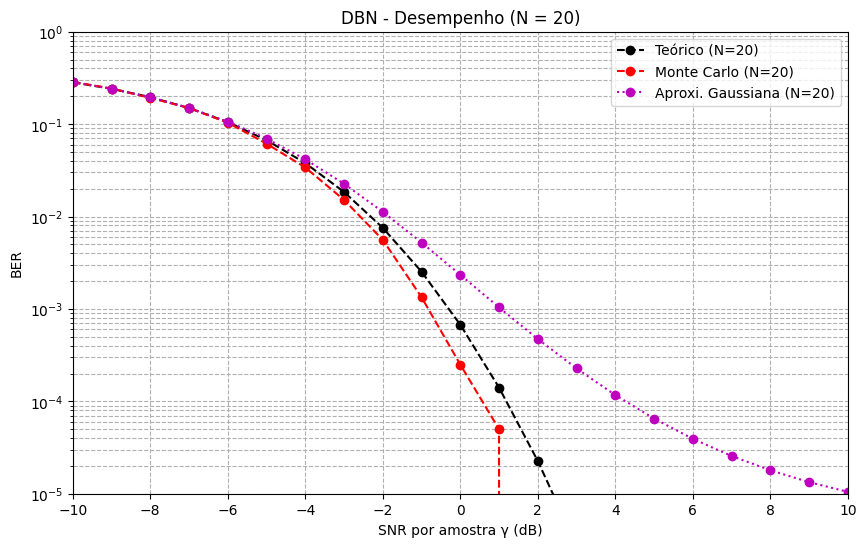

In [103]:
# ==============================
# 6. Plot
# ==============================
plt.figure(figsize=(10, 6))

plt.semilogy(snr_db_range, ber_theo, 'ko--', label=f'Teórico (N={N})')  # 'cor + marcador + linha (opcional)'
plt.semilogy(snr_db_range, ber_sim, 'ro--', label=f'Monte Carlo (N={N})')
plt.semilogy(snr_db_range, ber_appr, 'mo:', label=f'Aproxi. Gaussiana (N={N})')

plt.grid(True, which='both', linestyle='--')
plt.xlabel('SNR por amostra γ (dB)')
plt.ylabel('BER')
plt.title(f'DBN - Desempenho (N = {N})')
plt.legend()
plt.ylim(1e-5, 1) # Define o limite inferior do eixo Y para 10^-5 e o superior para 1
plt.xlim(-10, 10) # Define o limite inferior do eixo X para -10 e +10
plt.xticks(np.arange(-10, 11, 2)) # Define os ticks do eixo X de -10 a +10 com
plt.show()